In [1]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Dataset Titanic được load từ thư viện seaborn.  
Dataset chứa thông tin hành khách như tuổi, giới tính, hạng vé và trạng thái sống sót.  
Lệnh `head()` dùng để xem nhanh 5 dòng đầu tiên của dữ liệu.

In [2]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Kết quả `head()` cho thấy cấu trúc cơ bản của dataset Titanic.  
Có nhiều cột khác nhau bao gồm dữ liệu dạng số và dạng categorical.  
Điều này giúp kiểm tra dữ liệu đã được load đúng hay chưa.

In [3]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


Lệnh `tail()` hiển thị 5 dòng cuối cùng của dataset.  
Có thể dùng để kiểm tra dữ liệu ở cuối bảng và phát hiện lỗi load dữ liệu nếu có.  
Dữ liệu cuối dataset vẫn giữ cấu trúc giống các dòng đầu.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


`info()` cung cấp thông tin tổng quan về dataset.  
Có thể thấy số lượng dòng, tên cột, kiểu dữ liệu và số lượng giá trị non-null.  
Một số cột như `age`, `deck` và `embarked` có missing values.

In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


`describe()` cung cấp thống kê cơ bản cho các cột numeric.  
Có thể quan sát giá trị trung bình, min, max và các quartile.  
Điều này giúp hiểu sơ bộ phân bố dữ liệu.

In [6]:
df.shape

(891, 15)

`shape` cho biết số lượng dòng và cột của dataset.  
Dataset Titanic có nhiều thuộc tính khác nhau để phục vụ phân tích dữ liệu.  
Thông tin này giúp đánh giá kích thước dữ liệu trước khi xử lý.

In [7]:
missing_count = df.isnull().sum()

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})

print(missing_df)

             Missing Count  Missing Percent
survived                 0         0.000000
pclass                   0         0.000000
sex                      0         0.000000
age                    177        19.865320
sibsp                    0         0.000000
parch                    0         0.000000
fare                     0         0.000000
embarked                 2         0.224467
class                    0         0.000000
who                      0         0.000000
adult_male               0         0.000000
deck                   688        77.216611
embark_town              2         0.224467
alive                    0         0.000000
alone                    0         0.000000


Cột `deck` có số lượng missing values rất lớn nên có thể gây khó khăn cho việc phân tích.  
Cột `age` cũng thiếu khá nhiều dữ liệu vì không phải hành khách nào cũng được ghi nhận tuổi.  
Các cột như `embarked` hoặc `embark_town` chỉ thiếu một lượng nhỏ dữ liệu.

In [8]:
df["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

Dataset có số lượng hành khách nam nhiều hơn nữ.  
Điều này cho thấy phân bố giới tính không cân bằng.  
Sự khác biệt này có thể ảnh hưởng đến tỷ lệ sống sót.

In [9]:
df["pclass"].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

Hành khách hạng 3 chiếm số lượng lớn nhất trong dataset.  
Hạng 1 có ít hành khách hơn nhưng thường có điều kiện tốt hơn.  
Điều này có thể ảnh hưởng đến khả năng sống sót trên tàu.

In [10]:
df["embarked"].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Phần lớn hành khách lên tàu tại cảng Southampton (S).  
Các cảng Cherbourg (C) và Queenstown (Q) có ít hành khách hơn.  
Sự phân bố này phản ánh lượng hành khách khác nhau theo từng cảng.

In [11]:
print("Mean:", df["age"].mean())
print("Median:", df["age"].median())
print("Min:", df["age"].min())
print("Max:", df["age"].max())

Mean: 29.69911764705882
Median: 28.0
Min: 0.42
Max: 80.0


Tuổi trung bình của hành khách khoảng 29 tuổi.  
Có hành khách rất nhỏ tuổi và cũng có người cao tuổi.  
Một số giá trị tuổi có thể bị thiếu nên cần xử lý trước khi phân tích sâu hơn.

In [12]:
print("Mean:", df["fare"].mean())
print("Median:", df["fare"].median())
print("Min:", df["fare"].min())
print("Max:", df["fare"].max())

Mean: 32.204207968574636
Median: 14.4542
Min: 0.0
Max: 512.3292


Giá vé có sự chênh lệch rất lớn giữa các hành khách.  
Một số vé có giá cực kỳ cao so với phần lớn dữ liệu, cho thấy có outliers.  
Median thấp hơn mean khá nhiều nên dữ liệu bị lệch phải.

In [14]:
print("Mean:", df["sibsp"].mean())
print("Median:", df["sibsp"].median())
print("Min:", df["sibsp"].min())
print("Max:", df["sibsp"].max())

Mean: 0.5230078563411896
Median: 0.0
Min: 0
Max: 8


Phần lớn hành khách đi một mình hoặc đi cùng rất ít người thân.  
Tuy nhiên vẫn có trường hợp đi cùng nhiều anh chị em hoặc vợ/chồng.  
Giá trị lớn nhất khá cao nên có thể xem là trường hợp đặc biệt.

In [15]:
survival_rate = df["survived"].mean() * 100

print("Survival Rate:", survival_rate)

Survival Rate: 38.38383838383838


Tỉ lệ sống sót được tính bằng trung bình của cột `survived`.  
Kết quả cho thấy chỉ một phần hành khách sống sót sau thảm họa Titanic.  
Điều này phản ánh mức độ nghiêm trọng của tai nạn.

In [16]:
gender_survival = df.groupby("sex")["survived"].mean() * 100

print(gender_survival)

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


Hành khách nữ có tỉ lệ sống sót cao hơn nam giới rất nhiều.  
Điều này phù hợp với nguyên tắc “women and children first” khi sơ tán.  
Nam giới chịu ảnh hưởng lớn hơn trong thảm họa.

In [17]:
class_survival = df.groupby("pclass")["survived"].mean() * 100

print(class_survival)

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


Hành khách hạng 1 có tỉ lệ sống sót cao nhất.  
Hạng 3 có tỉ lệ sống sót thấp nhất do điều kiện tiếp cận xuồng cứu hộ khó khăn hơn.  
Điều này cho thấy địa vị xã hội ảnh hưởng đáng kể đến khả năng sống sót.

<Axes: >

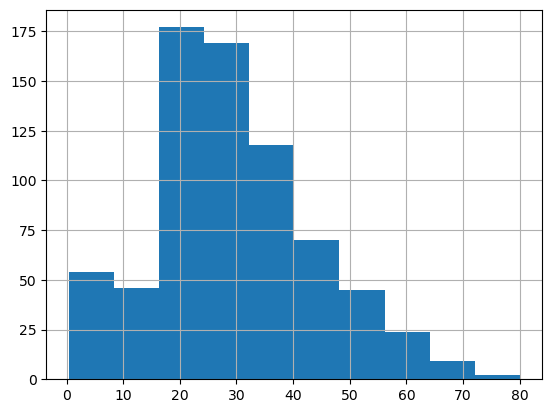

In [19]:
df["age"].hist()
#Nhóm tuổi nào nhiều nhất?

Phần lớn hành khách nằm trong độ tuổi trưởng thành trẻ.  
Số lượng trẻ em và người lớn tuổi ít hơn đáng kể.  
Dữ liệu tuổi phân bố không đồng đều.

In [20]:
df["pclass"].value_counts()
#Hạng vé nào có nhiều hành khách nhất?

pclass
3    491
1    216
2    184
Name: count, dtype: int64

Hạng vé thứ 3 có số lượng hành khách lớn nhất trên tàu Titanic.  
Điều này cho thấy đa số hành khách thuộc tầng lớp phổ thông.  
Hạng 1 có ít người hơn nhưng điều kiện tốt hơn.

In [21]:
df.groupby("survived")["fare"].mean()
#Người trả vé cao có sống sót nhiều hơn không?

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

Những người sống sót thường có mức giá vé trung bình cao hơn.  
Điều này cho thấy hành khách giàu hơn có cơ hội sống sót tốt hơn.  
Có thể do họ thuộc hạng vé cao và gần xuồng cứu hộ hơn.

## Đối chiếu dự đoán vs thực tế
## Dự đoán ban đầu
- Phụ nữ sẽ có tỉ lệ sống sót cao hơn nam giới.
- Hành khách hạng 1 sẽ sống sót nhiều hơn hạng 3.
- Người trả vé cao sẽ có khả năng sống sót tốt hơn.

## Đối chiếu kết quả thực tế

| Dự đoán | Kết quả |
|---|---|
| Phụ nữ sống sót cao hơn | Đúng |
| Hạng 1 sống sót cao hơn | Đúng |
| Vé đắt sống sót nhiều hơn | Đúng |

Kết quả phân tích cho thấy phần lớn dự đoán ban đầu đều chính xác.  
Giới tính và hạng vé ảnh hưởng mạnh đến khả năng sống sót của hành khách Titanic.  
Ngoài ra, mức giá vé cũng phản ánh sự khác biệt về điều kiện và cơ hội thoát nạn.

# New Questions From Analysis

1. Trẻ em có tỉ lệ sống sót cao hơn người lớn không?

2. Những người đi một mình có sống sót ít hơn người đi cùng gia đình không?

3. Cảng lên tàu (`embarked`) có ảnh hưởng đến tỉ lệ sống sót không?

4. Những người trả vé cực cao có thuộc chủ yếu hạng 1 không?

5. Độ tuổi trung bình của người sống sót và không sống sót khác nhau như thế nào?

In [22]:
children = df[df["age"] < 18]["survived"].mean() * 100

adults = df[df["age"] >= 18]["survived"].mean() * 100

print("Children Survival Rate:", children)
print("Adult Survival Rate:", adults)
#Trả lời câu hỏi 1

Children Survival Rate: 53.98230088495575
Adult Survival Rate: 38.10316139767055


Trẻ em có tỉ lệ sống sót cao hơn người lớn.  
Điều này phù hợp với ưu tiên cứu trẻ em trong quá trình sơ tán Titanic.  
Kết quả cho thấy độ tuổi là một yếu tố ảnh hưởng đến khả năng sống sót.

In [23]:
embarked_survival = df.groupby("embarked")["survived"].mean() * 100

print(embarked_survival)
#Trả lời câu hỏi 3 


embarked
C    55.357143
Q    38.961039
S    33.695652
Name: survived, dtype: float64


Tỉ lệ sống sót khác nhau giữa các cảng lên tàu.  
Một số cảng có hành khách thuộc hạng vé cao hơn nên khả năng sống sót cũng cao hơn.  
Điều này cho thấy nơi lên tàu có thể liên quan gián tiếp đến điều kiện của hành khách.